
# Física computacional: Tarea 3

Profesor: Pablo Benítez Llambay

Integrantes:
- Martín Raguileo Reyes
- Fernando Zamora Carrasco


#### **IMPORTANTE EJECUTAR ESTA CELDA PARA QUE SE EJECUTE EL CÓDIGO SIN PROBLEMAS**

In [1]:
import importlib
import subprocess
import sys

def install_if_missing(package, name=None):
    name = name or package
    try:
        importlib.import_module(package)
        print(f"'{package} ya está instalado.")
    except ImportError:
        print(f"Instalando '{package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", name])

packages = {
    "numpy": "numpy",
    "scipy": "scipy",
    "matplotlib": "matplotlib",
    "IPython": "ipython",
    "mpi4py": "mpi4py",
    "numba": "numba"
}

for pkg, name in packages.items():
    install_if_missing(pkg, name)

'numpy ya está instalado.
'scipy ya está instalado.
'matplotlib ya está instalado.
'IPython ya está instalado.
'mpi4py ya está instalado.
'numba ya está instalado.


In [2]:
import os
import shutil
import time
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from matplotlib.colors import Normalize
from mpi4py import MPI
import multiprocessing as mp
import numba

from matplotlib.artist import Artist
from numpy.typing import NDArray
from typing import Callable, List, Dict, Tuple, Optional
from IPython.display import Video, display, HTML, Math, Latex

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Introducción

La ecuación de Laplace es un pilar en áreas que van desde la electrostática hasta la dinámica de fluidos. En este informe se aborda la solución numérica de la ecuación de Laplace en dos dimensiones, $\nabla^{2}V=0$, para determinar el potencial electrostático $V(x,y)$ dentro de una región cuadraa libre de carga sujeta a condiciones de borde de Dirichlet.

Este trabajo implementa un enfoque estocástico basado en el método de Random Walk. Este método aprovecha la conexión teórica entre la difusión y la ecuación de Laplace, donde la solución en un punto interior puede interpretarse como el valor esperado del potencial en la frontera alcanzada por el caminante aleatorio. Si bien los métodos de Monte Carlo ofrecen ventajas en la implementación y manejor de geometrías complejas, presentan un desafío computacional significativo debido a su lenta convergencia estadística.

Para suplir este costo computacional de la simulación de miles de caminatas independientes, se integra una estrategia de computación paralela, en la que la naturaleza del cálculo permite una aceleración eficiente mediante técnicas de memoria compartida utilizando la librería multiprocessing.

Finalmente, el informe explora las propiedades físicas de la solución más allá del valor numérico. Se utiliza un análisis espectral mediante la transformada discreta de fourier (DFT/FFT) para estudiar cómo la ecuación de Laplace actúa como un filtro espacial, suavizando discontinuidades presentes en las condiciones de frontera. En este trabajo, no solo se busca resolver el sistema físico, sino también caracterizar el rendimiento y la escalabilidad de los algoritmos utilizados.

## Marco Teórico

**La ecuación de Laplace en electrostática**

El problema fundamental abordado en este trabajo es el cálculo del potencial electrostático $V(x,y)$ en una región libre de cargas. Según la teoría electromagnética clásica, en ausencia de fuentes de carga ($\rho = 0$), el potencial eléctrico satisface la Ecuación de Laplace:

$$\nabla^{2}V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0$$

Esta es una ecuación diferencial parcial elíptica de segundo orden. Las soluciones a esta ecuación, conocidas como funciones armónicas, poseen la propiedad del valor medio: el valor del potencial en un punto central es el promedio de los valores en una esfera (o círculo en 2D) que lo rodea. Esta propiedad es la base teórica que permite utilizar métodos de diferencias finitas y, crucialmente para este trabajo, métodos probabilísticos para encontrar su solución numérica. En este estudio, se considera una región cuadrada sujeta a condiciones de borde de Dirichlet, donde el potencial está fijo en las fronteras ($100V$ en la pared superior y $0V$ en las demás).

**Método Random Walk**

Cuando queremos resolver la Ecuación de Laplace en una grilla (una cuadrícula de puntos), podemos usar un método que dice que el valor del potencial en un punto es el promedio de los valores en sus cuatro vecinos más cercanos. Esto se expresa así:


$$V_{i,j} = \frac{1}{4}(V_{i+1,j} + V_{i-1,j} + V_{i,j+1} + V_{i,j-1})$$

Esta idea coincide con el comportamiento de un caminante aleatorio: una partícula que puede moverse al azar hacia arriba, abajo, izquierda o derecha con la misma probabilidad. Gracias a esto, podemos interpretar el potencial en un punto como el promedio del potencial en la parte de la frontera a la que llegue un caminante que empieza desde ese punto.


Para estimar el potencial en un punto interior:

1. Se suelta una “partícula virtual” desde ese punto.
2. La partícula camina al azar por la grilla, un paso a la vez.
3. Cuando llega a la frontera, se detiene.
4. Se registra el valor del potencial que tiene esa frontera (por ejemplo, 100 V en la pared superior y 0 V en las otras).
5. Se repite este proceso $M$ veces.

Al final, el potencial del punto se aproxima tomando el promedio de todos los valores de frontera obtenidos:

$$V(i,j) \approx \frac{1}{M} \sum_{k=1}^{M} V_{\text{borde}}^{(k)}$$

El error en este método es principalmente estadístico y disminuye lentamente: mejora como $1/\sqrt{M}$. Esto significa que se necesitan muchas caminatas para obtener buena precisión, pero a cambio el método tiene ventajas importantes.


## 1. Implementación del solver estocástico

#### Función de la caminata aleatoria.

In [3]:
def randomWalk_Laplace(args: Tuple[int, int, int, int]) -> float:
    """
    Estima el potencial V en una posición (i, j) usando Random Walk.
    
    Argumentos (empaquetados en una tupla para compatibilidad futura con multiprocessing):
    args: tupla (i, j, N, M)
        i, j: Coordenadas iniciales en la grilla (enteros)
        N: Tamaño de la grilla (NxN)
        M: Número de caminantes a simular
        
    Retorna:
    V_ij: El potencial estimado en el punto (i, j)
    """
    i_start, j_start, N, M = args


    # Si el punto ya está en el borde, retornamos su valor conocido.
    # Asumimos que los índices van de 0 a N-1.
    # Pared Superior (fila 0 en matriz visual, o fila N-1 dependiendo de tu sistema de coord).
    # Vamos a usar la convención matricial: 
    # i=0 (arriba), i=N-1 (abajo), j=0 (izquierda), j=N-1 (derecha).
    # Entonces:

    # Pared superior (y=L -> i=0) -> V=100
    if i_start == 0:
        return 100.0
    # Pared inferior (y=0 -> i=N-1) -> V=0
    if i_start == N - 1:
        return 0.0
    # Pared izquierda (x=0 -> j=0) -> V=0
    if j_start == 0:
        return 0.0
    # Pared derecha (x=L -> j=N-1) -> V=0
    if j_start == N - 1:
        return 0.0
    
    potencial_acumulado = 0.0

    # Definir los movimientos posibles: arriba, abajo, izquierda, derecha.
    # Moverse hacia abajo y hacia la derecha incrementa los índices.
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # (delta_i, delta_j)

    for _ in range(M):
        # Iniciar la caminata en (i_start, j_start)
        curr_i, curr_j = i_start, j_start

        while True:
            # Elegir un movimiento aleatorio
            move = random.choice(moves)
            curr_i += move[0]
            curr_j += move[1]

            # Verificar si hemos alcanzado el borde

            # Pared superior (i=0) -> 100V
            if curr_i <= 0:
                potencial_acumulado += 100.0
                break

            # Pared inferior (i=N-1) -> 0V
            if curr_i >= N-1:
                potencial_acumulado += 0.0
                break

            # Pared izquierda (j=0) -> 0V
            if curr_j <= 0:
                potencial_acumulado += 0.0
                break

            # Pared derecha (j=N-1) -> 0V
            if curr_j >= N-1:
                potencial_acumulado += 0.0
                break

    V_ij = potencial_acumulado / M
    return V_ij

#### Simulación con caminata aleatoria para resolver la ecuación de Laplace en 2D.

In [4]:
def RW_Laplace_Simulation(N: int, M: int)  -> Tuple[NDArray[np.float64], float]:
    # Inicializar la matriz de potencial
    V = np.zeros((N, N))

    # Establecer condiciones de borde en la matriz
    V[0, :] = 100.0 # Pared superior

    # Bucle principal de la simulación
    start_time = time.time()

    # Iteramos solo sobre los puntos interiores
    for i in range(1, N-1):
        for j in range(1, N-1):
            # Preparamos los argumentos
            args = (i, j, N, M)

            # Llamamos a la función de caminata aleatoria
            val = randomWalk_Laplace(args)

            # Guardamos el resultado
            V[i, j] = val

    end_time = time.time()
    T_1 = end_time - start_time

    return (V, T_1)

In [5]:
## Definir los parámetros de la simluación
N = 50
M = 1_000

print("Iniciando simulación serial de Laplace (Random Walk)...")
print(f"Grilla: {N}x{N} | Cantidad de caminantes por punto: {M}")

# Llamamos a la función de la simulación
V, T_1 = RW_Laplace_Simulation(N, M)

print("\nSimulación completada.")
print(f"Tiempo de ejecución serial (T_1): {T_1:4f} segundos ({T_1/60:.4f} minutos).")

Iniciando simulación serial de Laplace (Random Walk)...
Grilla: 50x50 | Cantidad de caminantes por punto: 1000

Simulación completada.
Tiempo de ejecución serial (T_1): 175.783277 segundos (2.9297 minutos).


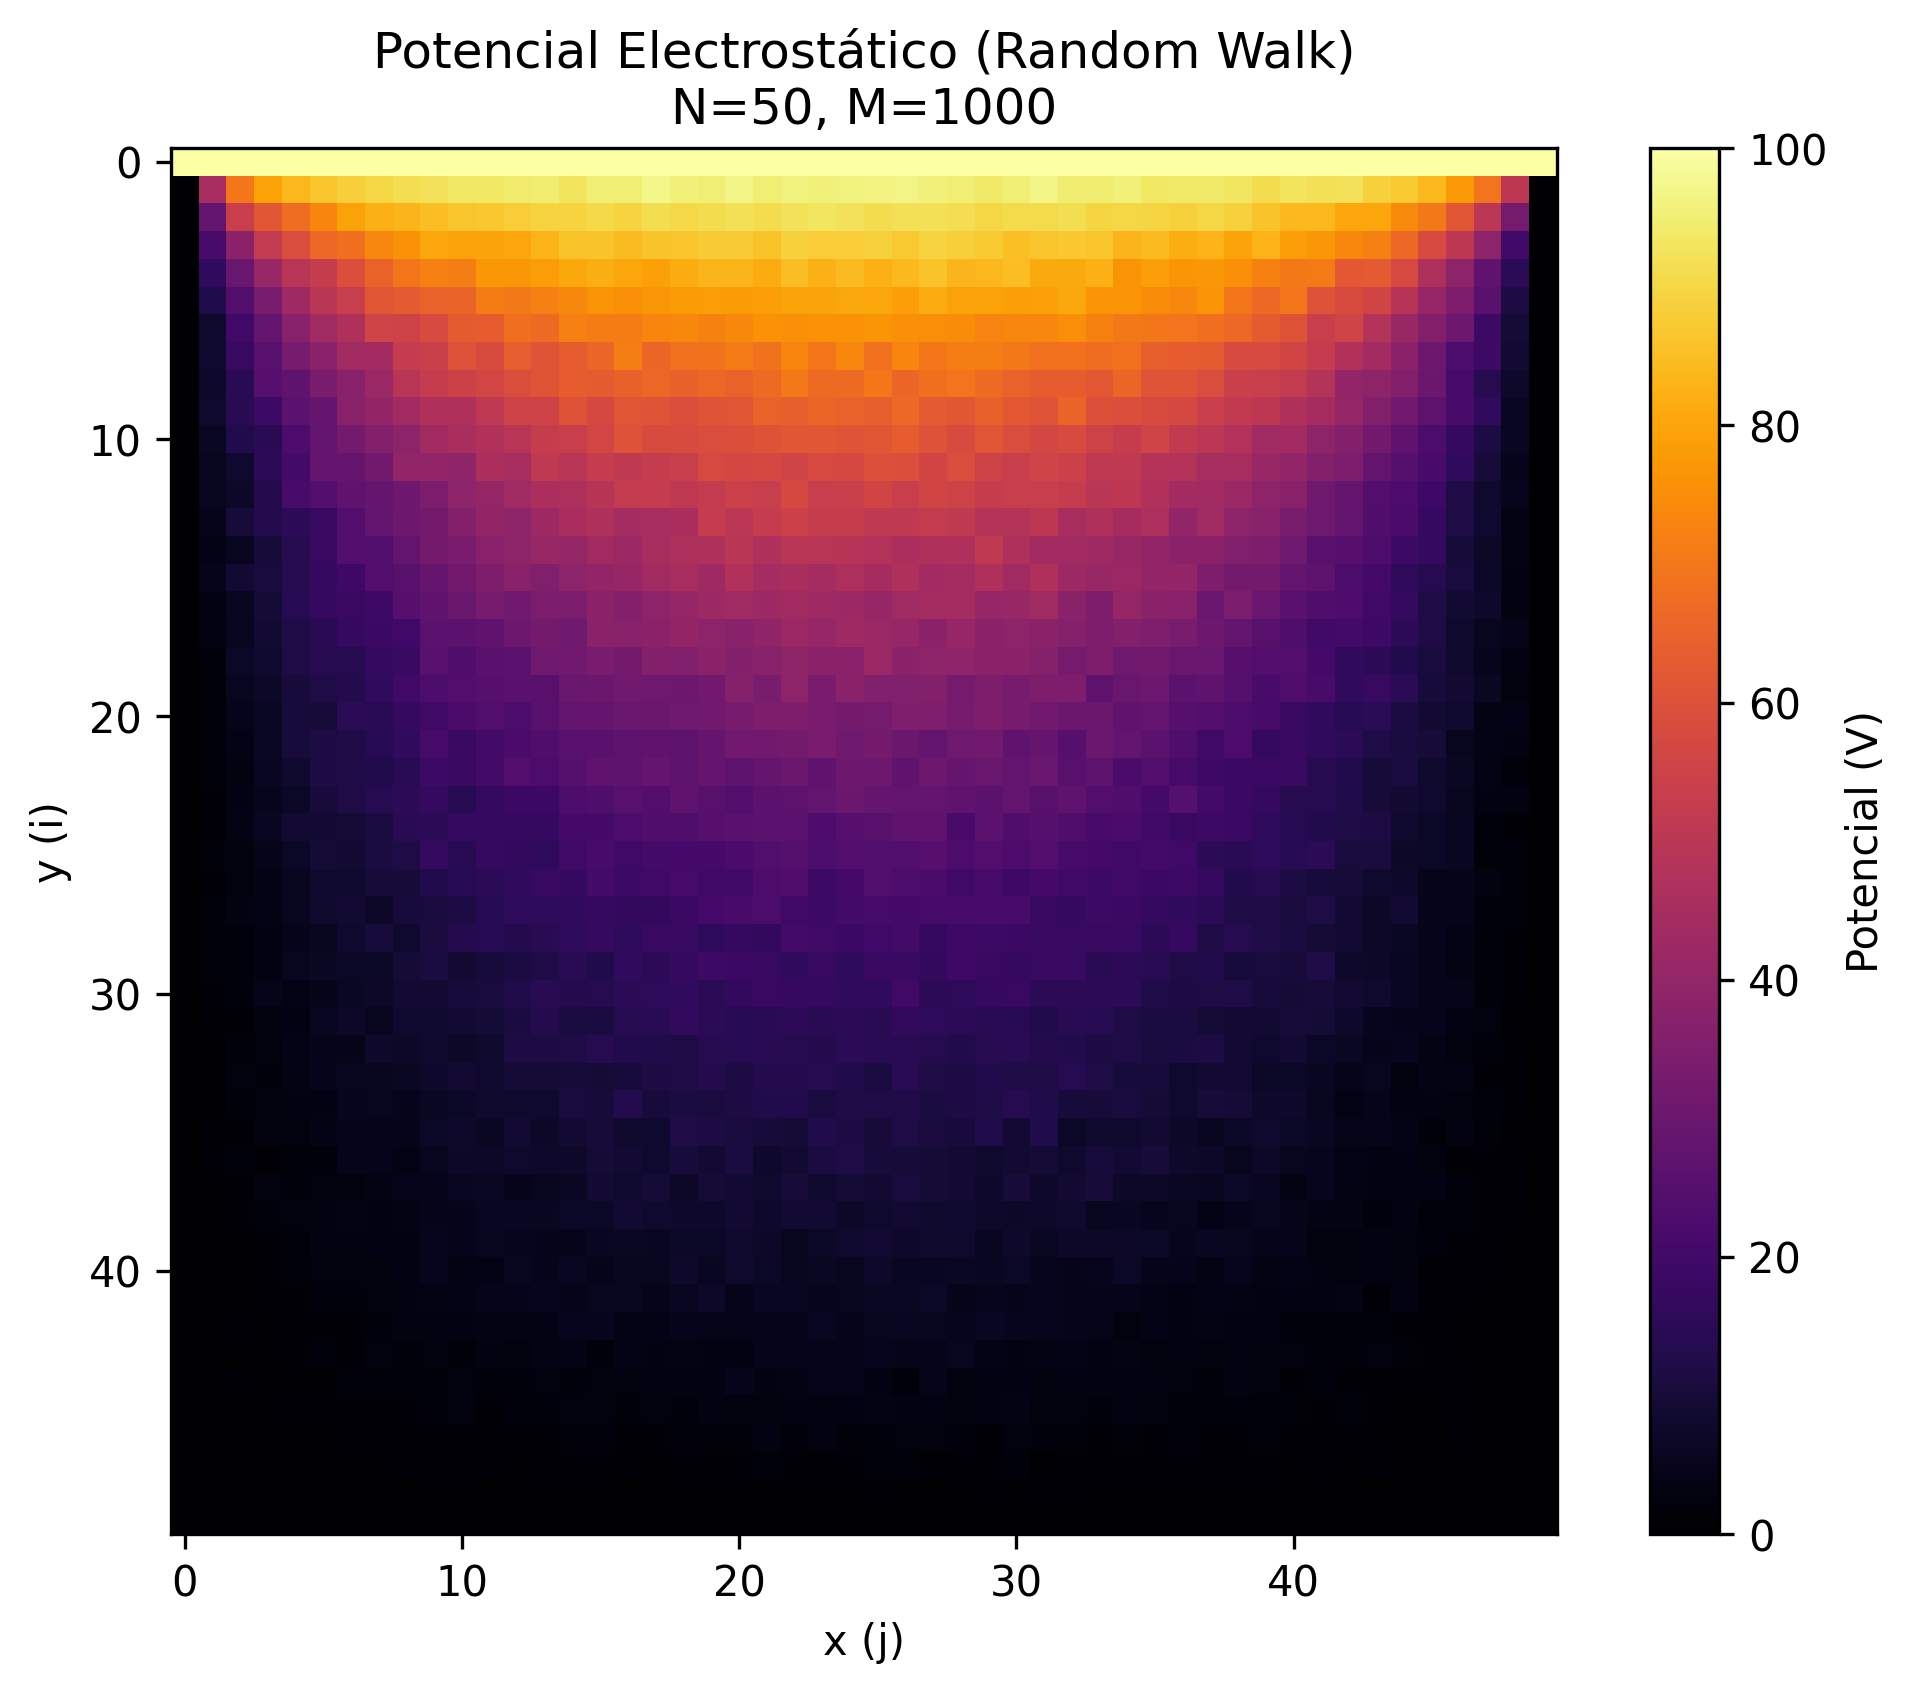

In [6]:
plt.figure(figsize=(8, 6), dpi=150)
plt.imshow(V, cmap='inferno', origin='upper')
plt.colorbar(label='Potencial (V)')
plt.title(f'Potencial Electrostático (Random Walk)\nN={N}, M={M}')
plt.xlabel('x (j)')
plt.ylabel('y (i)')
plt.show()

#### Animación del proceso de convergencia.

In [7]:
def convergence_animation(N: int, lista_M: List[int],
                          output_filename: str = "convergencia_laplace.mp4") -> str | None:
    """
    Genera una animación mostrando la solución para diferentes valores de M.
    
    Argumentos:
    - N: Tamaño de la grilla.
    - lista_M: Lista de enteros con los valores de M a simular (ej. [10, 50, 100]).
    - randomWalk_func: Tu función 'randomWalk_Laplace'.
    - output_filename: Nombre del archivo de salida.
    """

    # Preparamos el directorio
    output_dir = './media'
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)

    print(f"Creando animación para N={N}")
    frames = []

    # Generar los datos para cada cuadro (M)
    for idx, M in enumerate(lista_M):
        print(f"Simulado cuadro {idx+1}/{len(lista_M)} para M={M}")
        V_M, T_M = RW_Laplace_Simulation(N, M)
        frames.append(V_M)

    print("\nGenerando video...")

    # Configuración de la animación
    fig, ax = plt.subplots(figsize=(8, 7))

    # Escala de colores fija (0V a 100V)
    cax = ax.imshow(frames[0], cmap='inferno', origin='upper', vmin=0, vmax=100)
    cbar = fig.colorbar(cax, ax=ax, label='Potencial (V)')

    title = ax.set_title(f"Convergencia Random Walk\nN={N}, M={lista_M[0]}, T={T_M} [s]")
    ax.set_xlabel('x (j)')
    ax.set_ylabel('y (i)')

    # Función de actualización de la animación
    def update(frame_idx) -> List:
        V_data = frames[frame_idx]
        M_val = lista_M[frame_idx]

        cax.set_data(V_data)
        title.set_text(f"Convergencia Random Walk\nN={N}, Caminantes M={M_val}")
        return [cax, title]
    
    # Crear animación
    # fps=1 para apreciar el cambio
    anim = animation.FuncAnimation(fig, update, frames=len(lista_M),
                                   interval=1000, blit=True)
    
    try:
        anim.save(output_path, writer='ffmpeg', fps=1, dpi=150)
        print(f"Animación guardada exitosamente en: {output_path}")
    except Exception as e:
        print(f"Error al guardar animación: {e}")
        return None

    plt.close(fig)
    return output_path

In [8]:
N_anim = 50
# M_vals = [10, 50, 100, 200, 500, 1_000]
M_vals = [10, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000]

video_path = convergence_animation(N_anim, M_vals)

Creando animación para N=50
Simulado cuadro 1/10 para M=10
Simulado cuadro 2/10 para M=20
Simulado cuadro 3/10 para M=50
Simulado cuadro 4/10 para M=100
Simulado cuadro 5/10 para M=200
Simulado cuadro 6/10 para M=500
Simulado cuadro 7/10 para M=1000
Simulado cuadro 8/10 para M=2000
Simulado cuadro 9/10 para M=5000
Simulado cuadro 10/10 para M=10000

Generando video...
Animación guardada exitosamente en: ./media\convergencia_laplace.mp4


In [9]:
display(Video(video_path, embed=True, width=600))

#### Evolución del potencial para un número fijo de caminantes.

In [10]:
def single_random_walk(i_start: int, j_start: int, N: int) -> float:
    """
    Simula UN solo caminante y devuelve el valor obtenido (0 o 100).
    """
    # Condiciones de Borde inmediatas
    if i_start == 0:
        return 100.0
    if i_start == N - 1:
        return 0.0
    if j_start == 0:
        return 0.0
    if j_start == N - 1:
        return 0.0
    
    curr_i, curr_j = i_start, j_start
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    while True:
        move = random.choice(moves)
        curr_i += move[0]
        curr_j += move[1]

        if curr_i <= 0:
            return 100.0
        if curr_i >= N-1:
            return 0.0
        if curr_j <= 0:
            return 0.0
        if curr_j >= N-1:
            return 0.0

In [11]:
def simular_progresion(N: int, M: int, steps_per_frame:int = 10) -> List[NDArray[np.float64]]:
    """
    Genera una lista de matrices V que muestran la evolución del promedio
    a medida que se agregan caminantes.
    """
    print(f"Simulando progresión para N={N}, M={M}")
    
    # Matrices para acumular resultados
    V_sum = np.zeros((N, N)) # Suma de valores obtenidos
    V_counts = np.zeros((N, N)) # Cuántos caminantes han pasado por cada celda (será M al final)
    
    frames = []
    
    # Inicializar bordes en los frames para que se vea bonito desde el principio
    V_display = np.zeros((N, N))
    V_display[0, :] = 100.0
    frames.append(V_display.copy())
    
    # Simulamos caminantes para TODA la grilla simultáneamente (por lotes)
    # para que la animación muestre la imagen completa mejorando.
    
    # Total de caminatas a realizar por celda = M
    # Total de celdas interiores = (N-2)*(N-2)
    # Haremos rondas: en la ronda k, lanzamos el k-ésimo caminante para TODAS las celdas.
    
    for k in range(1, M + 1):
        # Lanzar 1 caminante para cada punto interior
        for i in range(1, N-1):
            for j in range(1, N-1):
                val = single_random_walk(i, j, N)
                V_sum[i, j] += val
                V_counts[i, j] += 1
        
        # Guardar un frame cada ciertos pasos (para no tener M frames)
        if k % steps_per_frame == 0 or k == 1 or k == M:
            # Calcular el promedio actual
            # Evitar división por cero (aunque V_counts >= 1 aquí)
            V_current = np.zeros((N, N))
            # Copiar bordes
            V_current[0, :] = 100.0
            
            # Calcular interior
            mask = V_counts > 0
            V_current[mask] = V_sum[mask] / V_counts[mask]
            
            frames.append(V_current)
                
    return frames

In [12]:
def animar_un_M(N: int, M: int, output_filename: str = "acumulacion_M.mp4", 
                steps_per_frame: int = 5) -> Optional[str]:
    # Preparar Directorio
    output_dir = "./media"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    
    # Generar Datos
    frames = simular_progresion(N, M, steps_per_frame)
    
    print(f"\nGenerando video con {len(frames)} cuadros...")
    
    # Configurar Figura
    fig, ax = plt.subplots(figsize=(8, 7))
    
    cax = ax.imshow(frames[0], cmap='inferno', origin='upper', vmin=0, vmax=100)
    cbar = fig.colorbar(cax, ax=ax, label='Potencial (V)')
    
    title_text = f"Solución de Laplace (Random Walk)\nN={N}, M={M} | Caminantes acumulados: 0"
    title = ax.set_title(title_text, fontsize=14)
    ax.set_xlabel('x (j)')
    ax.set_ylabel('y (i)')
    
    # Actualizar
    def update(frame_idx: int) -> List[Artist]:
        V_data = frames[frame_idx]
        # Calcular cuántos caminantes representa este frame
        # frame 0 es inicial. frame 1 es ronda 1... frame i es ronda (i*steps_per_frame) aprox
        if frame_idx == 0: walkers = 0
        else: walkers = min(M, (frame_idx) * steps_per_frame) # Aproximado para etiqueta
        
        if frame_idx == len(frames) - 1: walkers = M
        
        cax.set_data(V_data)
        title.set_text(f"Solución de Laplace (Random Walk)\nN={N}, M={M} | Caminantes acumulados: {walkers}")
        return [cax, title]
    
    # 5. Guardar
    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=100, blit=True) # Más rápido (10fps)
    
    try:
        anim.save(output_path, writer='ffmpeg', fps=10, dpi=150)
        print(f"Animación guardada en: {output_path}")
    except Exception as e:
        print(f"Error: {e}")
        return None
            
    plt.close(fig)
    return output_path

In [13]:
# Parámetros
N_anim = 50
M_target = 1_000 # Valor final de caminantes
steps_stride = 10 # Guardar estado cada 10 caminantes

# Generar video
video_path = animar_un_M(N_anim, M_target, "acumulacion_M_500.mp4", steps_stride)

# Mostrar el video
display(Video(video_path, embed=True, width=600))

Simulando progresión para N=50, M=1000

Generando video con 102 cuadros...
Animación guardada en: ./media\acumulacion_M_500.mp4


De las animaciones anteriores, podemos observar que a medida que aumentamos el número de caminantes, el potencial calculado converge hacia una solución estable, ya que un mayor número de caminantes reduce la variabilidad estadística en la estimación del potencial en cada punto de la grilla. Por otro lado, también podemos notar como al aumentar el número de caminantes, la solución converge con gran rapidez hacia una solución estable, lo que indica que el método de caminata aleatoria es eficiente para resolver la ecuación de Laplace en este contexto.

Sin embargo, es importante destacar que aunque el método converge rápidamente, al ser un método estocástico, siempre existirá cierta variabilidad en los resultados debido a la naturaleza aleatoria de las caminatas. Por lo tanto, para obtener resultados más precisos, es recomendable utilizar un número suficientemente grande de caminantes, al mismo tiempo de utilizar un valor de $N$ adecuado para representar en forma precisa la geometría del problema. Además, como se verá en las siguientes secciones, al ser un problema "Embarranssingly Parallel" podemos aprovechar la paralelización para reducir los tiempos de cómputo al aumentar el número de caminantes y el tamaño de la grilla, con el fin de obtener soluciones más precisas en tiempos razonables.

#### Comparación con la solución analítica.

In [24]:
def analytic_solution(x: int, y: int, L: int, n_terms: int = 100) -> float:
    """
    Calcula el potencial exacto V(x,y) usando la serie de Fourier.
    Bordes: V(x, L)=100, V=0 en los demás.
    """

    V = 0.0
    
    # Sumamos solo los términos impares (n = 1, 3, 5, ...) para optimizar
    for n in range(1, n_terms * 2, 2):
        # Coeficiente An para una onda cuadrada de amplitud 100
        A_n = 400.0 / (n * np.pi * np.sinh(n * np.pi))

        # Términos espaciales
        sin_x  = np.sin(n * np.pi * x / L)
        sinh_y = np.sinh(n * np.pi * y / L)

        V += A_n * sin_x * sinh_y

    return V

In [25]:
def error_analysis() -> tuple[list[int], list, list[int], list]:
    """
    Compara la solución numérica (RW) con la analítica variando M y N.
    Grafica los resultados.
    """
    
    # Asumimos una caja de 1x1 metro
    L_fisico = 1.0

    # Punto de prueba: El centro de la caja (x=0.5, y=0.5)
    x_target = L_fisico / 2.0
    y_target = L_fisico / 2.0

    # Valor real/exacto
    V_exacto = analytic_solution(x_target, y_target, L_fisico)

    ## Error vs M (Escalamiento estadístico)
    # Fijamos N constante y variamos M
    N_fijo = 50
    # Coordenadas de grilla para el centro
    i_center = N_fijo // 2
    j_center = N_fijo // 2

    M_values = [10, 20, 50, 100, 200, 500, 1_000, 2_000, 5_000, 10_000]
    errores_M = []

    for M in M_values:
        args = (i_center, j_center, N_fijo, M)
        V_num = randomWalk_Laplace(args)

        # Error relativo
        error = abs(V_num - V_exacto) / V_exacto
        errores_M.append(error)

    ## Error vs N (Escalamiento espacial)
    # Fijamos M muy grande para minimizar el ruido estadístico y ver el error de la grilla
    M_fijo = 10_000
    N_values = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
    errores_N = []
    
    for N in N_values:
        i = N // 2
        j = N // 2

        args = (i, j, N, M_fijo)
        V_num = randomWalk_Laplace(args)

        # Error relativo
        error = abs(V_num - V_exacto) / V_exacto
        errores_N.append(error)

    return (M_values, errores_M, N_values, errores_N)

Pendiente ajustada (Error vs M): -0.4024 (Teórico: -0.5)


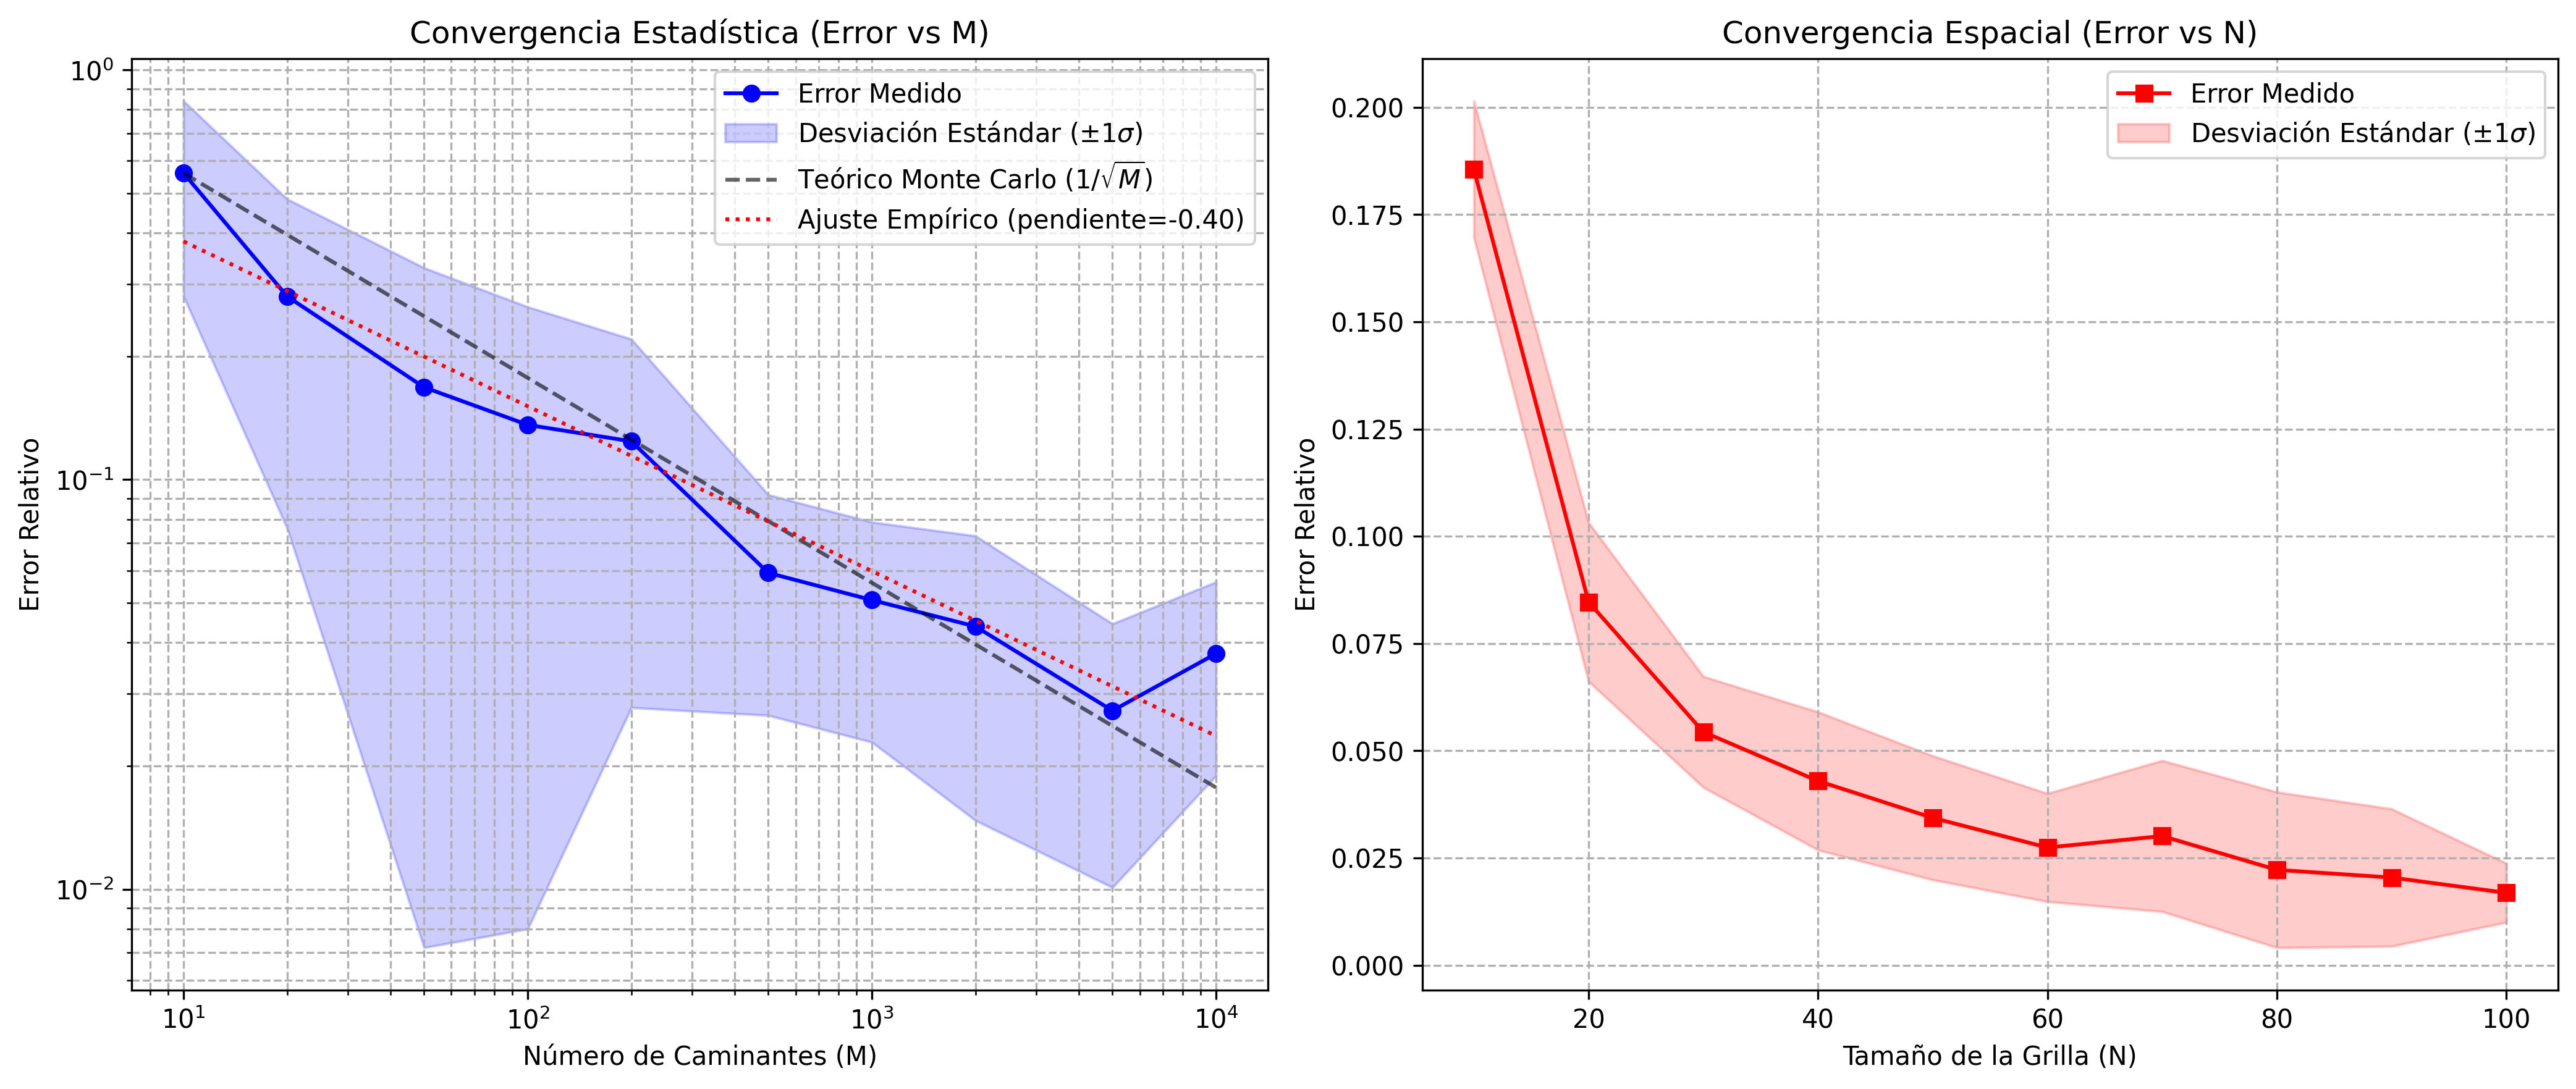

In [42]:
num_repeats = 10
M_errors_list, std_errores_M = [], []
N_errors_list, std_errores_N = [], []

for n in range(num_repeats):
    M_values, errores_M, N_values, errores_N = error_analysis()
    M_errors_list.append(errores_M)
    N_errors_list.append(errores_N)

# Calcular medias y desviaciones estándar
mean_M_errors = np.mean(M_errors_list, axis=0)
std_M_errors = np.std(M_errors_list, axis=0)
mean_N_errors = np.mean(N_errors_list, axis=0)
std_N_errors = np.std(N_errors_list, axis=0)

# Graficar Resultados
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# Error vs M
# Teoría: El error de Monte Carlo decae como 1/sqrt(M)
ax1.loglog(M_values, mean_M_errors, 'o-', label='Error Medido', color='blue')
M_lower_bound = np.maximum(mean_M_errors - std_M_errors, 1e-15)
M_upper_bound = mean_M_errors + std_M_errors
ax1.fill_between(M_values, M_lower_bound, M_upper_bound,
                 color='blue', alpha=0.2,
                 label=r'Desviación Estándar ($\pm 1\sigma$)')

# Línea teórica de referencia (pendiente -0.5)
ref_M = [mean_M_errors[0] * np.sqrt(M_values[0]) / np.sqrt(m) for m in M_values]
ax1.loglog(M_values, ref_M, 'k--', alpha=0.6, label=r'Teórico Monte Carlo ($1/\sqrt{M}$)')
ajuste_M = np.polyfit(np.log(M_values), np.log(mean_M_errors), 1)
pendiente_M = ajuste_M[0]
print(f"Pendiente ajustada (Error vs M): {pendiente_M:.4f} (Teórico: -0.5)")
ax1.loglog(M_values, np.exp(ajuste_M[1]) * np.array(M_values)**pendiente_M, 'r:', label=f'Ajuste Empírico (pendiente={pendiente_M:.2f})')

ax1.set_xlabel('Número de Caminantes (M)')
ax1.set_ylabel('Error Relativo')
ax1.set_title('Convergencia Estadística (Error vs M)')
ax1.grid(True, which="both", ls="--")
ax1.legend()

# Error vs N
# Teoría: Error de discretización espacial
ax2.plot(N_values, mean_N_errors, 's-', color='red', label='Error Medido')
N_lower_bound = np.maximum(mean_N_errors - std_N_errors, 1e-15)
N_upper_bound = mean_N_errors + std_N_errors
ax2.fill_between(N_values, N_lower_bound, N_upper_bound,
                 color='red', alpha=0.2,
                 label=r'Desviación Estándar ($\pm 1\sigma$)')
ax2.set_xlabel('Tamaño de la Grilla (N)')
ax2.set_ylabel('Error Relativo')
ax2.set_title('Convergencia Espacial (Error vs N)')
ax2.grid(True, ls="--")
ax2.legend()

plt.tight_layout()
plt.show();

De la gráfica anterior, podemos visualizar que, a medida que vamos aumentando el número de caminantes, el error relativo entre la solución numérica obtenida mediante caminatas aleatorias y la solución analítica disminuye con una razón aproximadamente proporcional a $1/\sqrt{M}$. Esto es consistente con la teoría de Monte Carlo, que establece que el error en estimaciones basadas en métodos estocásticos tiende a disminuir con la raíz cuadrada del número de muestras (en este caso, caminantes). Esto implica que para reducir el error en un factor de 10, se necesitaría aumentar el número de caminantes en un factor de 100, lo que indica una convergencia relativamente ineficiente pero predecible (dentro de lo esperado para métodos Monte Carlo).

Por otro lado, al observar la gráfica de error relativo en función del tamaño de la grilla $N$, podemos notar que el error disminuye a medida que aumentamos $N$. Esto se debe a que una grilla más fina permite una mejor representación de las condiciones de borde y del potencial en el interior de la región, lo que conduce a una solución numérica más precisa. La relación entre el error y $N$ no es tan directa como con $M$, pero generalmente se espera que el error disminuya a medida que $N$ aumenta, aunque la tasa exacta puede depender de varios factores, incluyendo la implementación específica del método y las condiciones del problema.

Aun así, en ambos casos, hay que tener en cuenta que debido a la naturaleza estocástica del método, siempre habrá cierta variabilidad en los resultados, y es importante considerar esta incertidumbre al interpretar los resultados numéricos obtenidos mediante caminatas aleatorias. Es por ello que se realizaron múltiples repeticiones para cada configuración de $M$ y $N$, con el fin de estimar la desviación estándar del error y así tener una mejor comprensión de la precisión de los resultados obtenidos. De este último, podemos observar que, aunque el error promedio disminuye con $M$ y $N$, la desviación estándar muestra una gran variabilidad en los resultados, lo que implica que, incluso con un gran número de caminantes y una grilla fina, los resultados pueden variar significativamente entre diferentes ejecuciones del algoritmo. Este fenómeno puede ser un factor importante a la hora de escoger este método para resolver problemas prácticos, ya que la incertidumbre inherente puede afectar la confiabilidad de las soluciones obtenidas.

## 2. Aceleración paralela

In [27]:
utils_path = os.path.abspath(os.path.join(os.getcwd(), 'utils'))
if utils_path not in sys.path:
    sys.path.append(utils_path)

from simulacion_paralela import run_parallel_simulation

# Parámetros de la simulación para benchmarking
N_bench = 50
M_bench = 5_000

# Obtener el número máximo de núcleos disponibles en tu CPU
max_cores = mp.cpu_count()

# Definir los valores de p (núcleos) a probar: 1, 2, 4, ... hasta max_cores
p_values = [1]
while p_values[-1] * 2 <= max_cores:
    p_values.append(p_values[-1] * 2)
if p_values[-1] != max_cores:
    p_values.append(max_cores)

# Listas para guardar los resultados
times = []      # Tiempos de ejecución (T_p)
speedups = []   # Aceleración (S_p)
V_final = None  # Para guardar la matriz de potencial final (del caso más rápido)

print(f"Iniciando análisis de escalabilidad")
print(f"Grilla: {N_bench}x{N_bench}, Caminantes: {M_bench}\n")
print(f"{'Procesos (p)':<15} | {'Tiempo (s)':<15} | {'Speedup (S_p)':<15}")
print(f"----------------|-----------------|----------------")

# Bucle de ejecución
T_1 = None # Tiempo serial base

for p in p_values:
    # Llamamos a tu función importada.
    # run_parallel_simulation devuelve (V_matriz, tiempo_ejecucion)
    V_p, t_p = run_parallel_simulation(N_bench, M_bench, p)
    
    # Guardamos el tiempo
    times.append(t_p)
    
    # Calculamos Speedup
    if p == 1:
        T_1 = t_p
        s_p = 1.0
    else:
        s_p = T_1 / t_p
    
    speedups.append(s_p)
    
    # Guardamos la matriz resultante (puedes guardar solo la última o todas en un dict)
    V_final = V_p
    
    print(f"{p:<15} | {t_p:<15.4f} | {s_p:<15.2f}")

print("\nAnálisis completado.")

Iniciando análisis de escalabilidad
Grilla: 50x50, Caminantes: 5000

Procesos (p)    | Tiempo (s)      | Speedup (S_p)  
----------------|-----------------|----------------
1               | 884.9339        | 1.00           
2               | 579.3311        | 1.53           
4               | 385.7995        | 2.29           
8               | 212.7794        | 4.16           
16              | 153.0305        | 5.78           

Análisis completado.


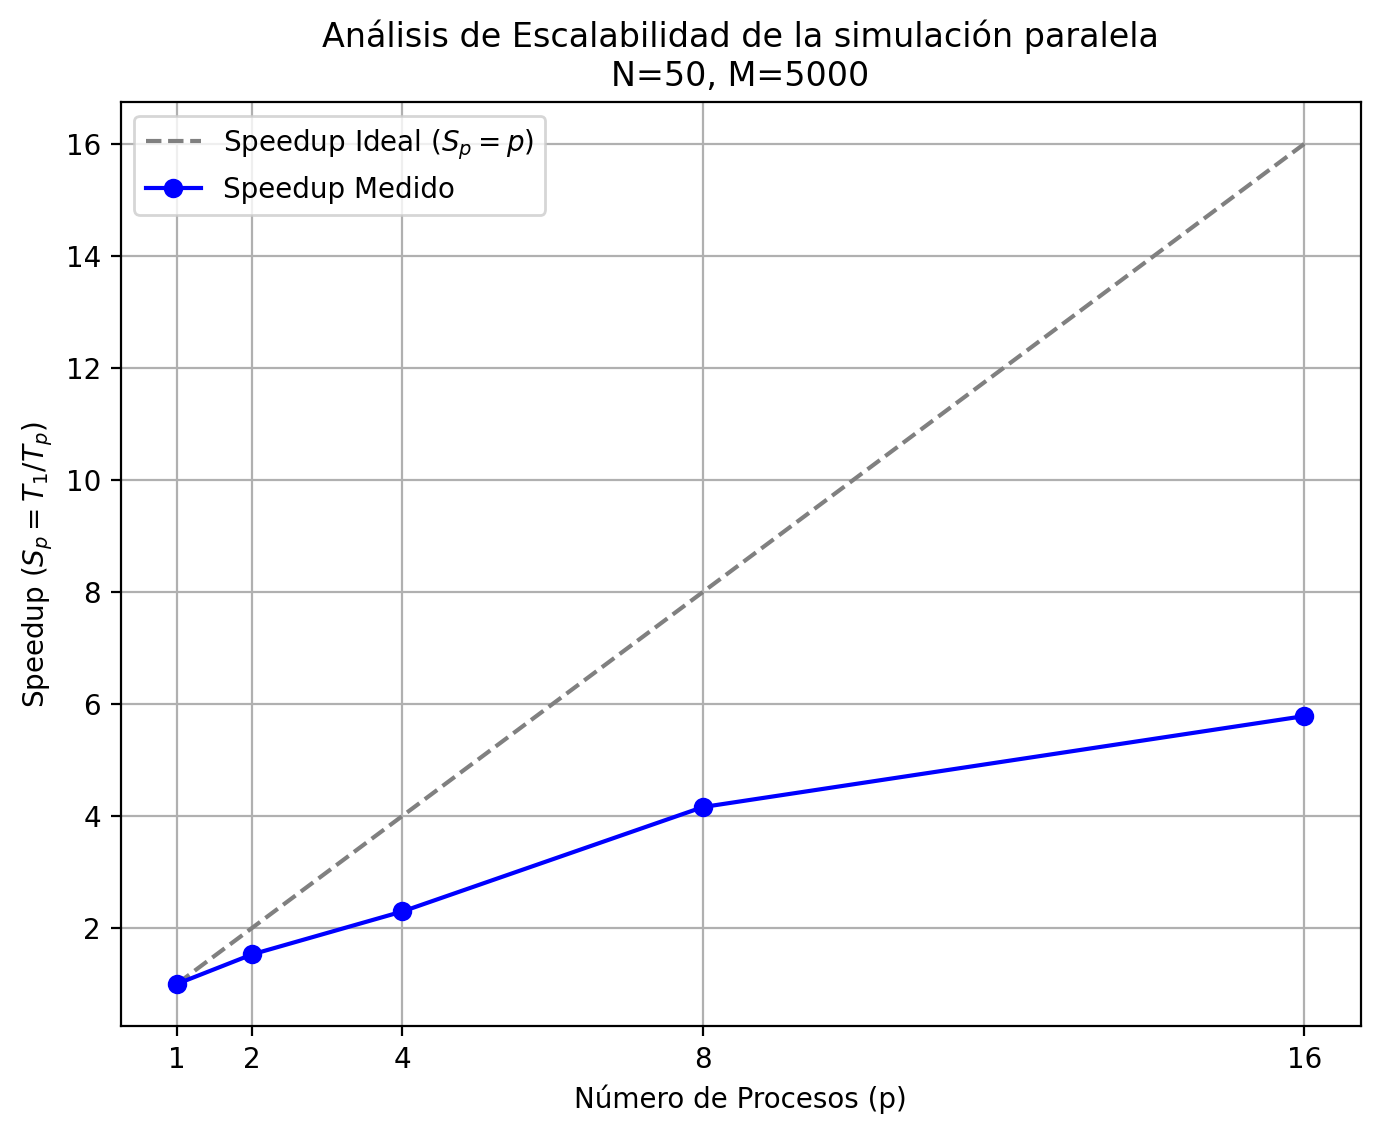

In [28]:
plt.figure(figsize=(8, 6))

# Curva ideal (lineal)
plt.plot(p_values, p_values, '--', color='gray', label=r'Speedup Ideal ($S_p = p$)')

# Curva medida
plt.plot(p_values, speedups, 'o-', label='Speedup Medido', color='blue')

plt.xticks(p_values)
plt.xlabel('Número de Procesos (p)')
plt.ylabel(r'Speedup ($S_p = T_1 / T_p$)')
plt.title(f'Análisis de Escalabilidad de la simulación paralela\nN={N_bench}, M={M_bench}')
plt.grid(True)
plt.legend()
plt.show()

Se puede evidenciar en el gráfico que el Speedup medido tiene un comportamiento claramente sub-lineal, donde la ganancia de rendimiento disminuye a medida que se añaden más núcleos de procesamiento. Si bien se logra una aceleración efectiva respecto a la ejecución serial ($S_p > 1$), la curva experimental diverge progresivamente de la recta ideal ($S_p = p$). Específicamente, para la simulación realizada, se observa que al utilizar 16 procesos el Speedup alcanza un valor cercano a 6, lo cual representa una eficiencia inferior al 40% respecto al máximo teórico, a pesar de que el cálculo de caminatas independientes se clasifica conceptualmente como un problema "Embarrassing parallelism".

Esta desviación de la linealidad se atribuye principalmente al overhead o costo computacional fijo asociado a la gestión de la librería `multiprocessing`. Dado que el tamaño de la grilla ($N = 50$) no es masivo, el tiempo que el sistema invierte en inicializar los intérpretes independientes y en la serialización y deserialización de datos para comunicar los resultados representa una fracción significativa del tiempo total. Cuando este costo administrativo se vuelve comparable respecto al tiempo efectivo de cómputo destinado a las caminatas aleatorias, la eficiencia del paralelismo disminuye drásticamente y limita la escalabilidad del algoritmo.

Asimismo, se observa una saturación evidente en la pendiente del Speedup al pasar de 8 a 16 procesos, lo cual sugiere que el hardware utilizado probablemente dispone de 8 núcleos físicos. Al sobrepasar esa cantidad, el sistema recurre al Hyper-threading para habilitar núcleos lógicos adicionales, los cuales no duplican la capacidad real de procesamiento para tareas intensivas en CPU. En consecuencia, el rendimiento deja de crecer de manera significativa y la curva de Speedup tiende a aplanarse en su extremo derecho, reflejando tanto las limitaciones arquitectónicas del equipo como el impacto del overhead intrínseco al modelo de paralelización empleado.


## 3. Análisis espectral

In [29]:
## Definir los parámetros de la simluación
N_p3 = 51
M_p3 = 10_000

print("Iniciando simulación serial de Laplace (Random Walk)...")
print(f"Grilla: {N_p3}x{N_p3} | Cantidad de caminantes por punto: {M_p3}")

# Llamamos a la función de la simulación
V_p3, T_p3 = run_parallel_simulation(N_p3, M_p3, num_procs=16)

print("\nSimulación completada.")
print(f"Tiempo de ejecución serial (T_p3): {T_p3:4f} segundos ({T_p3/60:.4f} minutos).")

Iniciando simulación serial de Laplace (Random Walk)...
Grilla: 51x51 | Cantidad de caminantes por punto: 10000

Simulación completada.
Tiempo de ejecución serial (T_p3): 323.340724 segundos (5.3890 minutos).


In [30]:
# Perfil del Borde Superior (o muy cerca de él, ej: fila 1)
# Representa la señal "cuadrada" original llena de frecuencias altas.
perfil_borde = V_p3[0, :].copy()
perfil_borde[0] = 0; perfil_borde[-1] = 0

# Perfil del Centro de la caja
# Representa la señal "suavizada" por Laplace.
perfil_centro = V_p3[N_p3 // 2, :]

# 2. Calcular FFT
F_borde = np.fft.fft(perfil_borde)
F_centro = np.fft.fft(perfil_centro)

# 3. Centrar las frecuencias (IMPORTANTE)
# numpy devuelve las frecuencias en orden [0, 1, ... , -2, -1]
# fftshift las ordena de [-N/2 ... 0 ... N/2] para graficar bien.
F_borde_shifted = np.fft.fftshift(F_borde)
F_centro_shifted = np.fft.fftshift(F_centro)

# 4. Calcular Espectro de Potencia (|F|^2)
# Normalizamos por N^2 para que la magnitud no dependa del tamaño de la grilla
P_borde = np.abs(F_borde_shifted)**2 / (N_p3**2)
P_centro = np.abs(F_centro_shifted)**2 / (N_p3**2)

# 5. Definir el eje de Frecuencia Espacial (k)
freqs = np.fft.fftfreq(N_p3)
k_vals = np.fft.fftshift(freqs) * N_p3  # k como índice (-N/2 a N/2)

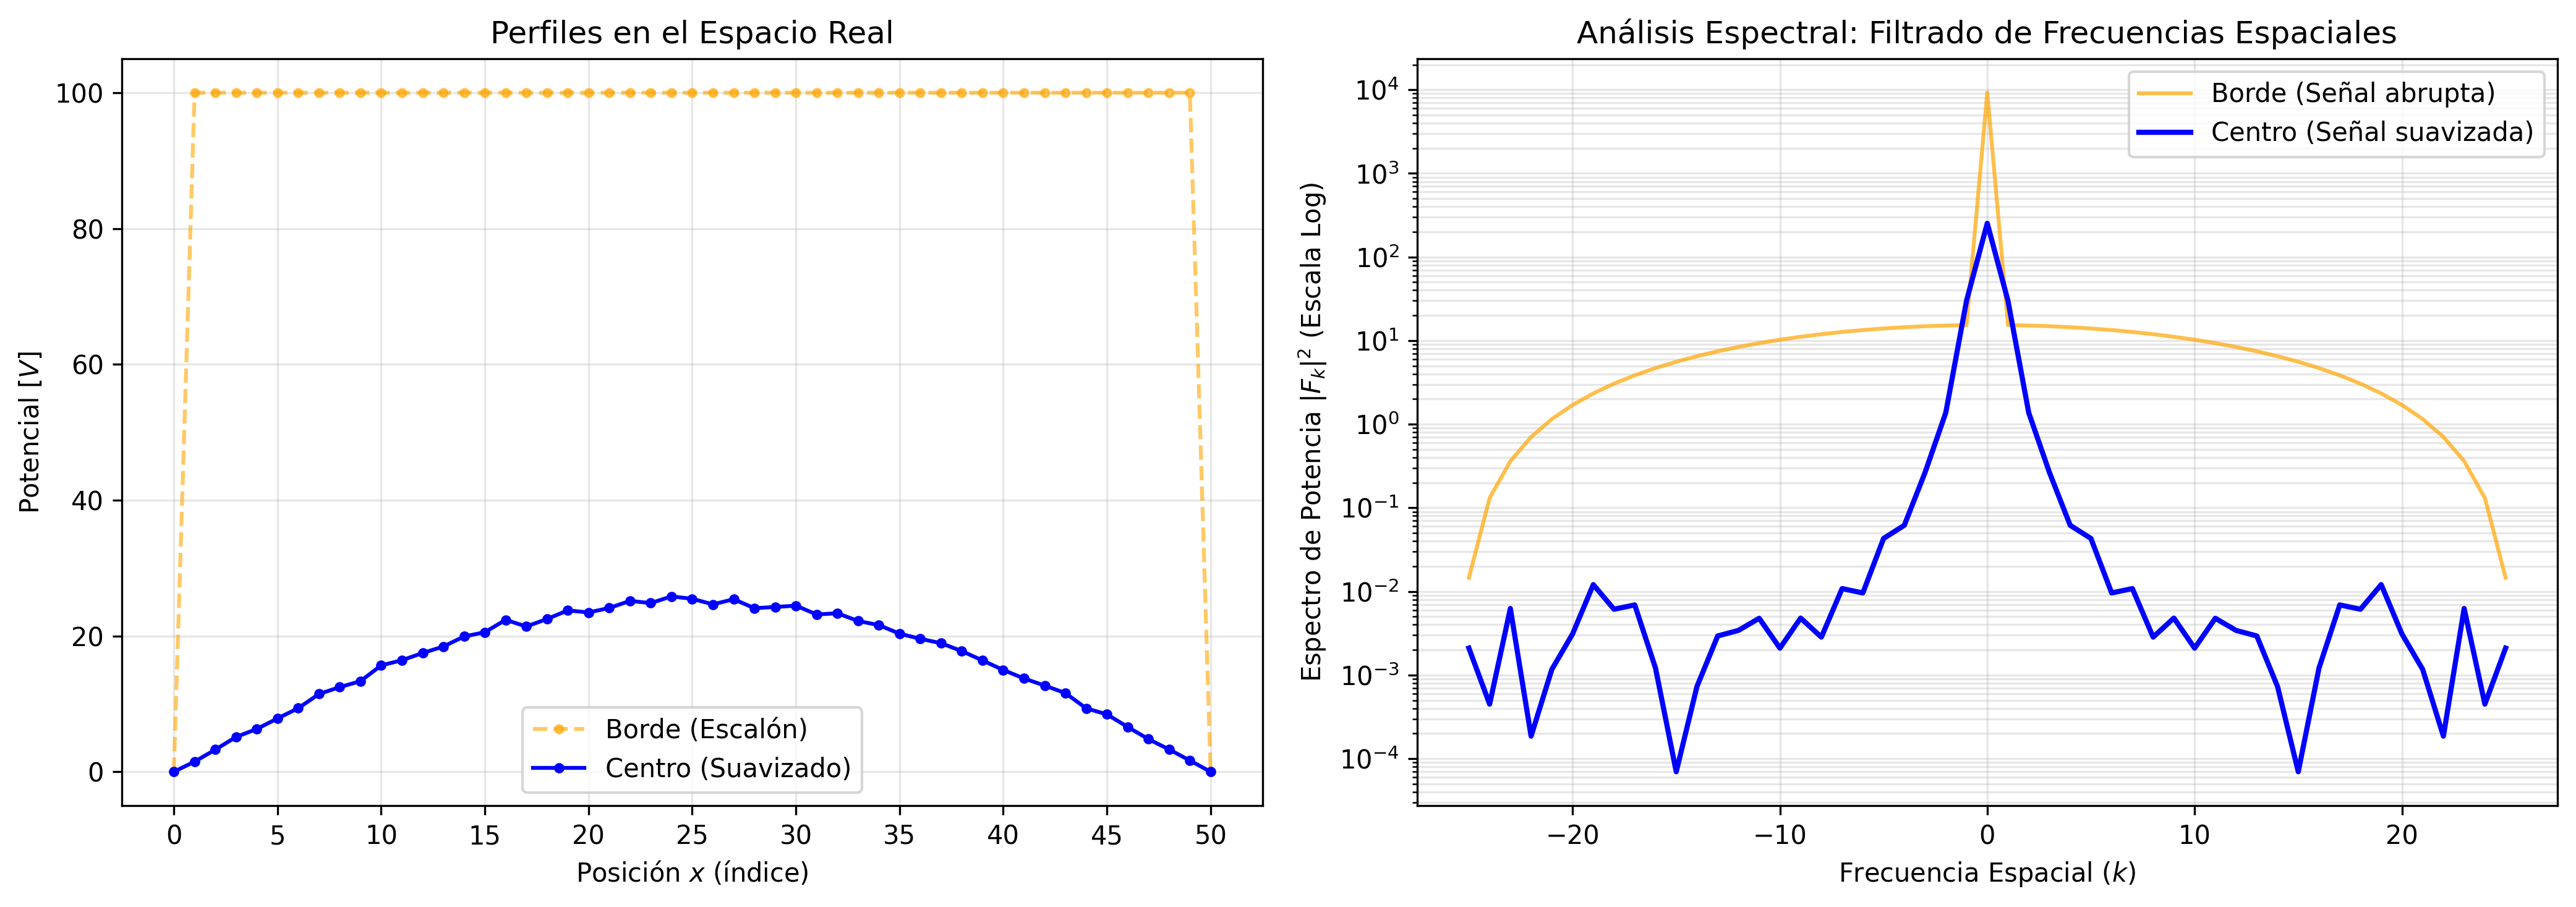

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Plot A: Espacio Real
ax1.plot(perfil_borde, 'o--', label='Borde (Escalón)', color='orange', markersize=3, alpha=0.6)
ax1.plot(perfil_centro, 'o-', label='Centro (Suavizado)', color='blue', markersize=3)
ax1.set_xticks(range(0, N_p3, 5))
ax1.set_xlabel(r"Posición $x$ (índice)")
ax1.set_ylabel(r"Potencial [$V$]")
ax1.set_title("Perfiles en el Espacio Real")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot B: Espectro de Amplitud (Simétrico)
plt.semilogy(k_vals, P_borde, label='Borde (Señal abrupta)', color='orange', alpha=0.7)
plt.semilogy(k_vals, P_centro, label='Centro (Señal suavizada)', color='blue', linewidth=2)

plt.title("Análisis Espectral: Filtrado de Frecuencias Espaciales")
plt.xlabel(r"Frecuencia Espacial ($k$)")
plt.ylabel(r"Espectro de Potencia $|F_k|^2$ (Escala Log)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.tight_layout()
plt.show();

## 4. Referencias